# Tactical Role Clustering in the Premier League

For this project, I used the **FBref Premier League 2024/25 player statistics dataset** to explore whether players can be grouped by statistical role rather than only by listed position. Traditional labels such as defender, midfielder, and forward are useful, but they do not always capture how modern players actually contribute on the field.

The main goal is to use per-90 attacking and progression metrics to identify broad tactical profiles, such as goal-focused forwards, creative/progressive attackers, and players with lower attacking involvement.


## README: Dataset and Reproducibility

To run this notebook, place the dataset file **`fbref_PL_2024-25.csv`** in the same folder as the notebook. The dataset comes from Kaggle: **FBref Premier League 2024/25 Player Stats Dataset** by Siddhraj Thakor.

Dataset URL: https://www.kaggle.com/datasets/siddhrajthakor/fbref-premier-league-202425-player-stats-dataset

If starting from a fresh download, download the CSV from Kaggle, rename it exactly as `fbref_PL_2024-25.csv` if necessary, and then run all notebook cells from top to bottom.


## Required Libraries

This notebook uses the following Python libraries:

- pandas
- numpy
- matplotlib
- seaborn
- scikit-learn
- pathlib (part of the Python standard library)

If any external package is missing, it can be installed with:

```bash
pip install pandas numpy matplotlib seaborn scikit-learn
```


## Reproducibility Note

The analysis is reproducible because the same CSV file is loaded directly with pandas, all cleaning and feature engineering steps are shown in the notebook, and the K-Means model uses `random_state=42` with `n_init=10`. A reader using the same `fbref_PL_2024-25.csv` file in the same folder should be able to rerun the notebook and reach the same K-Means results.


## Step 1: Load and Inspect the Dataset

The first step loads the CSV file into a pandas DataFrame and checks the basic structure of the data. This includes the number of rows and columns, the first few records, column names, data types, and missing values. The notebook expects the dataset file to be named exactly `fbref_PL_2024-25.csv` and to be saved in the same folder as this notebook.


In [1]:
# Step 1: Load and inspect the dataset

import pandas as pd
import numpy as np
from pathlib import Path

# Create folder for saved report figures
Path("figures").mkdir(exist_ok=True)

# Load the dataset
df = pd.read_csv("fbref_PL_2024-25.csv")

# Show dataset size
print("Dataset shape:", df.shape)

# Show first few rows
print("\nFirst 5 rows:")
print(df.head())

# Show all column names
print("\nColumns:")
print(df.columns.tolist())

# Show basic dataset info
print("\nDataset info:")
df.info()

# Show numerical summary statistics for the raw dataset
print("\nNumerical summary:")
print(df.describe())

# Check missing values
print("\nMissing values:")
print(df.isnull().sum())


Dataset shape: (574, 36)

First 5 rows:
   Rk             Player   Nation    Pos        Squad   Age    Born  MP  \
0   1         Max Aarons  eng ENG     DF  Bournemouth  24.0  2000.0   3   
1   2  Joshua Acheampong  eng ENG     DF      Chelsea  18.0  2006.0   4   
2   3        Tyler Adams   us USA     MF  Bournemouth  25.0  1999.0  28   
3   4   Tosin Adarabioyo  eng ENG     DF      Chelsea  26.0  1997.0  22   
4   5      Simon Adingra   ci CIV  FW,MF     Brighton  22.0  2002.0  29   

   Starts   Min  ...  Gls.1  Ast.1  G+A.1  G-PK.1  G+A-PK  xG.1  xAG.1  \
0       1    86  ...   0.00   0.00   0.00    0.00    0.00  0.00   0.00   
1       2   170  ...   0.00   0.00   0.00    0.00    0.00  0.12   0.00   
2      21  1965  ...   0.00   0.14   0.14    0.00    0.14  0.07   0.05   
3      15  1409  ...   0.06   0.06   0.13    0.06    0.13  0.06   0.01   
4      12  1097  ...   0.16   0.16   0.33    0.16    0.33  0.20   0.20   

   xG+xAG  npxG.1  npxG+xAG.1  
0    0.00    0.00        0.00  


## Step 2: Clean and Prepare the Dataset

Players have very different amounts of playing time, so raw season totals are not always fair for comparison. I filtered out players below 600 minutes because very small samples can distort per-90 statistics. I kept the cutoff at 600 instead of using a stricter threshold such as 900 minutes so that the dataset would still include rotation players and not only regular starters.

In this step, I also created per-90 versions of progressive carries, progressive passes, and progressive receptions. I renamed the existing per-90 attacking columns so the feature names were easier to read later in the notebook.


In [2]:
# Step 2: Clean and prepare the dataset

# Make a copy so the original dataframe stays unchanged
players = df.copy()

# Filter out players with very low minutes
# This helps avoid extreme per-90 stats from players who barely played
players = players[players["Min"] >= 600].copy()

# Create per-90 progression metrics
players["PrgC_per90"] = players["PrgC"] / players["90s"]
players["PrgP_per90"] = players["PrgP"] / players["90s"]
players["PrgR_per90"] = players["PrgR"] / players["90s"]

# Rename existing per-90 columns to clearer names
players = players.rename(columns={
    "Gls.1": "Gls_per90",
    "Ast.1": "Ast_per90",
    "G+A.1": "G+A_per90",
    "xG.1": "xG_per90",
    "xAG.1": "xAG_per90",
    "npxG.1": "npxG_per90",
    "npxG+xAG.1": "npxG+xAG_per90"
})

# Check the cleaned dataset
print("Original dataset shape:", df.shape)
print("Cleaned dataset shape:", players.shape)

players[[
    "Player", "Squad", "Pos", "Min", "90s",
    "Gls_per90", "Ast_per90", "npxG_per90", "xAG_per90",
    "PrgC_per90", "PrgP_per90", "PrgR_per90"
]].head()


Original dataset shape: (574, 36)
Cleaned dataset shape: (369, 39)


,Player,Squad,Pos,Min,90s,Gls_per90,Ast_per90,npxG_per90,xAG_per90,PrgC_per90,PrgP_per90,PrgR_per90
2,Tyler Adams,Bournemouth,MF,1965,21.8,0.00,0.14,0.07,0.05,0.642202,3.486239,0.458716
3,Tosin Adarabioyo,Chelsea,DF,1409,15.7,0.06,0.06,0.06,0.01,0.318471,2.675159,0.063694
4,Simon Adingra,Brighton,"FW,MF",1097,12.2,0.16,0.16,0.20,0.20,4.098361,1.475410,11.147541
5,Emmanuel Agbadou,Wolves,DF,1410,15.7,0.06,0.00,0.05,0.02,0.382166,1.974522,0.127389
7,Ola Aina,Nott'ham Forest,DF,2995,33.3,0.06,0.03,0.02,0.04,2.012012,3.213213,2.012012


## Cleaned Dataset Size

The original dataset contains **574 players**. After the 600-minute filter, the cleaned dataset contains **369 players**, so **205 low-minute players** were removed. This gave me a more reliable sample for per-90 comparisons while still keeping a broad mix of Premier League players and tactical roles.


## Exploratory Data Analysis

Before modeling, I looked at the cleaned dataset to understand which types of players were included and how the main features behaved. These EDA plots help explain the shape of the data before applying clustering.


### EDA Figure 1: Player Counts by Primary Position

This countplot shows the balance of primary listed positions after the 600-minute filter. I use the first listed position for hybrid labels such as `FW,MF`, so the chart gives a simpler view of the cleaned sample.


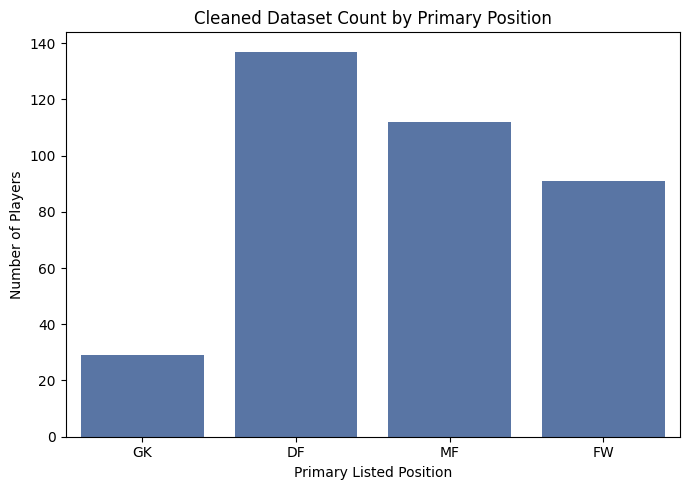

In [3]:
# EDA Figure 1: Player counts by primary position

import matplotlib.pyplot as plt
import seaborn as sns

players["Primary_Pos"] = players["Pos"].str.split(",").str[0]
position_order = ["GK", "DF", "MF", "FW"]

plt.figure(figsize=(7, 5))
sns.countplot(data=players, x="Primary_Pos", order=position_order, color="#4C72B0")
plt.title("Cleaned Dataset Count by Primary Position")
plt.xlabel("Primary Listed Position")
plt.ylabel("Number of Players")
plt.tight_layout()
plt.savefig("figures/eda_position_counts.png", dpi=300, bbox_inches="tight")
plt.show()


### EDA Figure 2: Minutes Distribution

This histogram shows the spread of playing time in the cleaned dataset. Even after filtering out very low-minute players, the sample still includes both rotation players and full-season regulars.


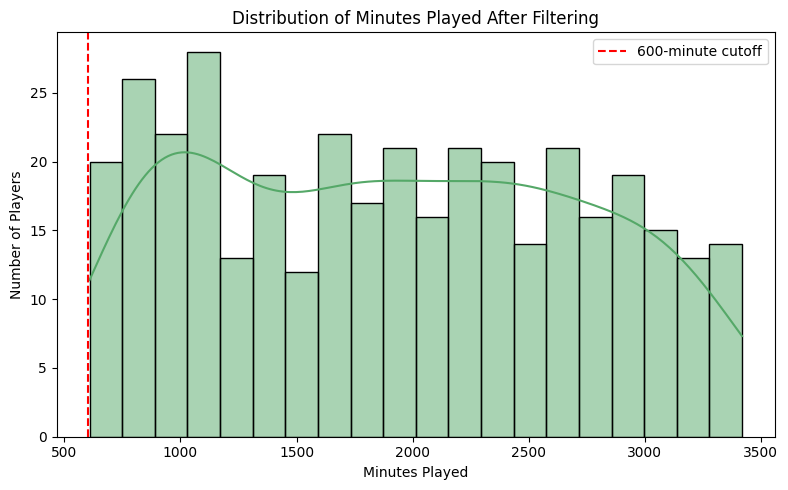

In [4]:
# EDA Figure 2: Distribution of minutes played

plt.figure(figsize=(8, 5))
sns.histplot(data=players, x="Min", bins=20, kde=True, color="#55A868")
plt.axvline(600, color="red", linestyle="--", label="600-minute cutoff")
plt.title("Distribution of Minutes Played After Filtering")
plt.xlabel("Minutes Played")
plt.ylabel("Number of Players")
plt.legend()
plt.tight_layout()
plt.savefig("figures/eda_minutes_distribution.png", dpi=300, bbox_inches="tight")
plt.show()


### EDA Figure 3: Correlation Between Candidate Features

This heatmap shows how the candidate clustering features relate to each other. It helps check whether scoring, creativity, and progression metrics capture different parts of a player's attacking profile.


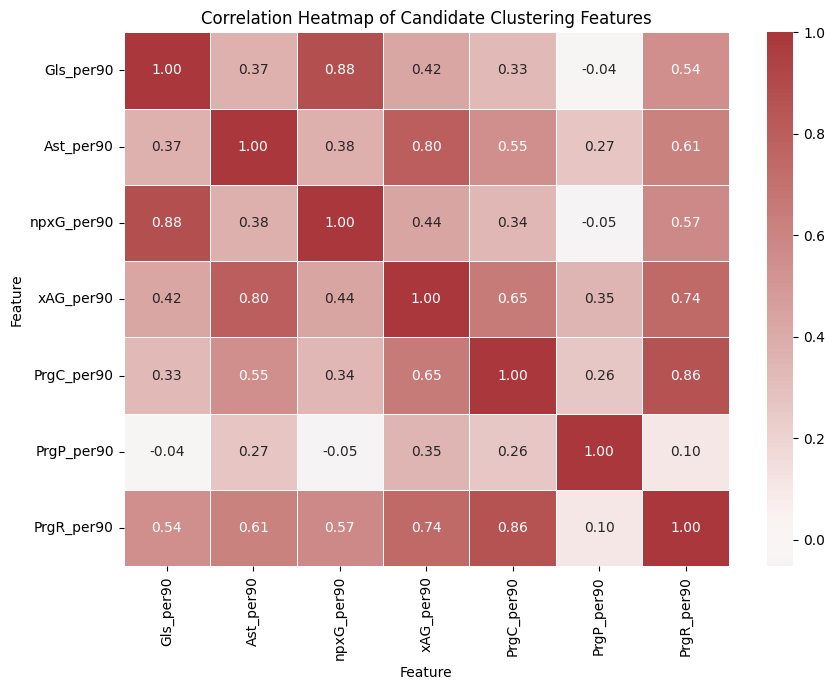

In [5]:
# EDA Figure 3: Correlation heatmap of candidate clustering features

eda_features = [
    "Gls_per90",
    "Ast_per90",
    "npxG_per90",
    "xAG_per90",
    "PrgC_per90",
    "PrgP_per90",
    "PrgR_per90"
]

plt.figure(figsize=(9, 7))
sns.heatmap(
    players[eda_features].corr(),
    annot=True,
    cmap="vlag",
    center=0,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Heatmap of Candidate Clustering Features")
plt.xlabel("Feature")
plt.ylabel("Feature")
plt.tight_layout()
plt.savefig("figures/eda_correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## Step 3: Select and Scale Clustering Features

I selected seven tactical features for clustering: goals, assists, non-penalty expected goals, expected assisted goals, progressive carries, progressive passes, and progressive receptions. I chose these because they connect directly to my research question about attacking contribution and ball progression.

`npxG_per90` means **non-penalty expected goals per 90 minutes**. I used it because it measures scoring chance quality while reducing the effect of penalty-taking responsibilities.

I standardized the features with `StandardScaler` because K-Means is distance-based. Without scaling, features with larger numerical ranges could have too much influence on the clusters.

One important limitation is that these features are attacking-focused. The model is not meant to fully evaluate defensive value, pressing, shot-stopping, or goalkeeper-specific performance.


In [6]:
# Step 3: Select features and scale the data

from sklearn.preprocessing import StandardScaler

# Select the tactical features we want to use for clustering
features = [
    "Gls_per90",
    "Ast_per90",
    "npxG_per90",
    "xAG_per90",
    "PrgC_per90",
    "PrgP_per90",
    "PrgR_per90"
]

# Create the feature matrix
X = players[features].copy()

# Scale the features so they are all on the same scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Convert the scaled array back into a DataFrame for easier viewing
X_scaled_df = pd.DataFrame(X_scaled, columns=features, index=players.index)

print("Selected features:")
print(features)

print("\nScaled feature data shape:", X_scaled_df.shape)

X_scaled_df.head()


Selected features:
['Gls_per90', 'Ast_per90', 'npxG_per90', 'xAG_per90', 'PrgC_per90', 'PrgP_per90', 'PrgR_per90']

Scaled feature data shape: (369, 7)


,Gls_per90,Ast_per90,npxG_per90,xAG_per90,PrgC_per90,PrgP_per90,PrgR_per90
2,-0.790161,0.440313,-0.411782,-0.558365,-0.723074,0.069518,-0.918173
3,-0.424557,-0.321142,-0.485867,-1.026630,-0.939496,-0.366048,-1.041225
4,0.184784,0.630676,0.551319,1.197630,1.587462,-1.010338,2.411456
5,-0.424557,-0.892233,-0.559952,-0.909564,-0.896915,-0.742304,-1.021384
7,-0.424557,-0.606687,-0.782206,-0.675431,0.192681,-0.077102,-0.434313


## Step 4: Evaluate Possible Cluster Counts

K-Means requires choosing the number of clusters in advance. This step compares values of `k` from 2 to 10 using inertia from the elbow method and silhouette score. The goal is to find a cluster count that is both statistically reasonable and useful for football interpretation. Silhouette scores closer to 1 generally indicate better-separated clusters.


    k      inertia  silhouette_score
0   2  1554.435151          0.398240
1   3  1277.490277          0.387765
2   4  1055.601667          0.258625
3   5   930.595817          0.255613
4   6   829.841152          0.269247
5   7   771.976195          0.269418
6   8   730.045209          0.261609
7   9   684.516663          0.258266
8  10   645.100131          0.239579


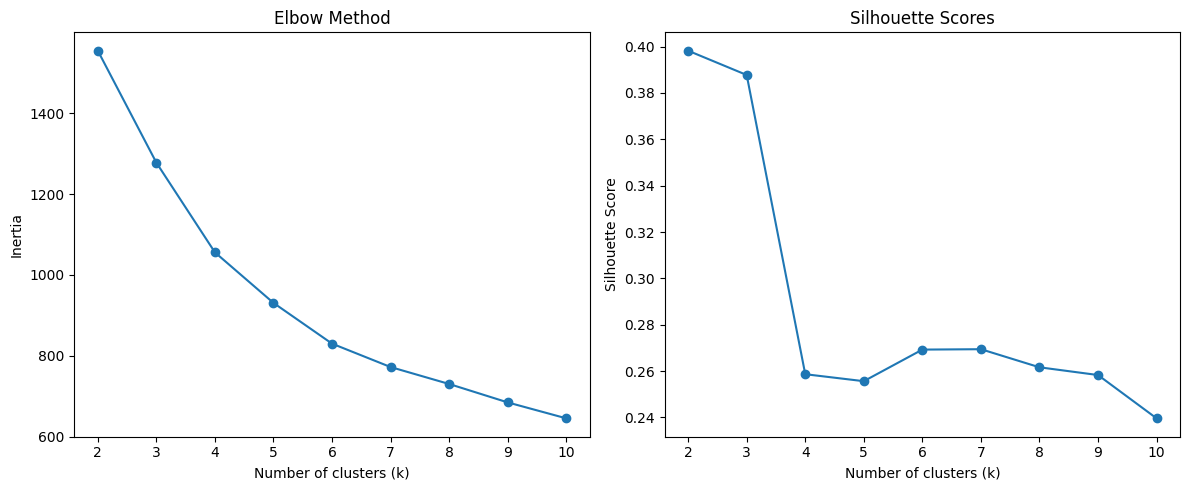

In [7]:
# Step 4: Evaluate possible numbers of clusters

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Try different numbers of clusters
k_values = range(2, 11)

inertia_values = []
silhouette_values = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    cluster_labels = kmeans.fit_predict(X_scaled)

    inertia_values.append(kmeans.inertia_)
    silhouette_values.append(silhouette_score(X_scaled, cluster_labels))

# Put the results into a dataframe
cluster_eval = pd.DataFrame({
    "k": list(k_values),
    "inertia": inertia_values,
    "silhouette_score": silhouette_values
})

print(cluster_eval)

# Plot elbow method and silhouette scores
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(cluster_eval["k"], cluster_eval["inertia"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.subplot(1, 2, 2)
plt.plot(cluster_eval["k"], cluster_eval["silhouette_score"], marker="o")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores")

plt.tight_layout()
plt.savefig("figures/kmeans_evaluation.png", dpi=300, bbox_inches="tight")
plt.show()


## Cluster Count Decision

Although `k = 2` had the highest silhouette score, it mostly separated players into a broad low-attacking group and a broad attacking group. That split was statistically clean, but it was not very useful for my research question.

I selected `k = 3` because it still had a similar silhouette score and created a more meaningful separation between goal-scoring forwards and creative/progressive attackers. In other words, I chose the final cluster count using both the quantitative evaluation and the football interpretation.


## Step 5: Fit the Final K-Means Model

Based on the evaluation results, the final model uses three clusters. This provides more tactical detail than two clusters while still keeping the groups interpretable. Each player receives a cluster label that will be analyzed in later steps.


In [8]:
# Step 5: Fit the final K-Means model

# Based on the elbow method and silhouette scores, use 3 clusters
final_k = 3

kmeans = KMeans(n_clusters=final_k, random_state=42, n_init=10)
players["Cluster"] = kmeans.fit_predict(X_scaled)

# Show how many players are in each cluster
print("Number of players in each cluster:")
print(players["Cluster"].value_counts().sort_index())

# Preview players with their assigned clusters
players[[
    "Player", "Squad", "Pos", "Min", "Cluster",
    "Gls_per90", "Ast_per90", "npxG_per90", "xAG_per90",
    "PrgC_per90", "PrgP_per90", "PrgR_per90"
]].head(15)


Number of players in each cluster:
Cluster
0    227
1     43
2     99
Name: count, dtype: int64


,Player,Squad,Pos,Min,Cluster,Gls_per90,Ast_per90,npxG_per90,xAG_per90,PrgC_per90,PrgP_per90,PrgR_per90
2,Tyler Adams,Bournemouth,MF,1965,0,0.00,0.14,0.07,0.05,0.642202,3.486239,0.458716
3,Tosin Adarabioyo,Chelsea,DF,1409,0,0.06,0.06,0.06,0.01,0.318471,2.675159,0.063694
4,Simon Adingra,Brighton,"FW,MF",1097,2,0.16,0.16,0.20,0.20,4.098361,1.475410,11.147541
5,Emmanuel Agbadou,Wolves,DF,1410,0,0.06,0.00,0.05,0.02,0.382166,1.974522,0.127389
7,Ola Aina,Nott'ham Forest,DF,2995,0,0.06,0.03,0.02,0.04,2.012012,3.213213,2.012012
8,Rayan Aït-Nouri,Wolves,DF,3109,2,0.12,0.20,0.08,0.16,2.579710,3.130435,5.101449
9,Kristoffer Ajer,Brentford,DF,1438,0,0.00,0.00,0.06,0.08,1.687500,3.500000,2.750000
10,Manuel Akanji,Manchester City,DF,2014,0,0.00,0.00,0.07,0.02,2.053571,7.053571,0.312500
11,Nathan Aké,Manchester City,DF,678,0,0.00,0.00,0.03,0.00,1.600000,6.666667,0.266667
13,Carlos Alcaraz,Everton,"FW,MF",764,2,0.24,0.35,0.20,0.19,2.235294,4.941176,2.470588


## CS590 Additional Analysis: Agglomerative Clustering Comparison

To make the analysis more rigorous, K-Means is compared with Agglomerative Clustering using the same scaled feature matrix and the same number of clusters. This checks whether the tactical groupings are reasonably stable across clustering approaches rather than being only an artifact of one algorithm.


In [9]:
# Additional model comparison: Agglomerative Clustering

from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import adjusted_rand_score

agg_model = AgglomerativeClustering(n_clusters=3)
agg_labels = agg_model.fit_predict(X_scaled)

agg_silhouette = silhouette_score(X_scaled, agg_labels)
kmeans_silhouette = silhouette_score(X_scaled, players["Cluster"])

comparison = pd.DataFrame({
    "Model": ["K-Means", "Agglomerative Clustering"],
    "Number of Clusters": [3, 3],
    "Silhouette Score": [kmeans_silhouette, agg_silhouette]
})

print(comparison)

# Compare how similar the two clustering methods are
ari = adjusted_rand_score(players["Cluster"], agg_labels)
print("Adjusted Rand Index between K-Means and Agglomerative Clustering:", round(ari, 3))

                      Model  Number of Clusters  Silhouette Score
0                   K-Means                   3          0.387765
1  Agglomerative Clustering                   3          0.204836
Adjusted Rand Index between K-Means and Agglomerative Clustering: 0.245


## Model Comparison Interpretation

The comparison model is used as a robustness check, but the final interpretation still uses K-Means because it produced a higher silhouette score for the selected three-cluster structure. The Adjusted Rand Index measures how similar the two algorithms' assignments are; a lower value suggests that some player assignments depend on the clustering method, which is a useful limitation to acknowledge.


## Step 6: Summarize the Clusters

This step calculates the average per-90 statistics for each cluster and compares the original listed positions inside each group. These summaries are used to understand what each cluster represents tactically instead of assigning labels based only on guesswork.


In [10]:
# Step 6: Summarize and interpret the clusters

# Calculate average values for each cluster
cluster_summary = players.groupby("Cluster")[features].mean().round(3)

print("Average per-90 stats by cluster:")
print(cluster_summary)

# Also show the most common listed positions in each cluster
print("\nPosition counts by cluster:")
position_counts = pd.crosstab(players["Cluster"], players["Pos"])
print(position_counts)

cluster_summary


Average per-90 stats by cluster:
         Gls_per90  Ast_per90  npxG_per90  xAG_per90  PrgC_per90  PrgP_per90  \
Cluster                                                                        
0            0.041      0.042       0.049      0.051       1.028       3.243   
1            0.413      0.094       0.390      0.102       1.564       2.037   
2            0.211      0.213       0.186      0.204       3.388       4.191   

         PrgR_per90  
Cluster              
0             1.538  
1             5.003  
2             6.996  

Position counts by cluster:
Pos       DF  DF,FW  DF,MF  FW  FW,DF  FW,MF  GK  MF  MF,DF  MF,FW
Cluster                                                           
0        114      3      6   3      0      5  29  52      8      7
1          0      0      0  30      0      7   0   3      0      3
2         11      1      2  17      1     28   0  18      1     20


,Gls_per90,Ast_per90,npxG_per90,xAG_per90,PrgC_per90,PrgP_per90,PrgR_per90
Cluster,,,,,,,
0,0.041,0.042,0.049,0.051,1.028,3.243,1.538
1,0.413,0.094,0.390,0.102,1.564,2.037,5.003
2,0.211,0.213,0.186,0.204,3.388,4.191,6.996


## Goalkeeper Interpretation Note

Goalkeepers are included because the dataset contains all player positions, but the selected features focus on attacking output and ball progression. As a result, goalkeepers naturally appear in the **Defensive / Low-Attacking Involvement** cluster. This should be interpreted as low attacking involvement within the chosen feature set, not as a complete evaluation of goalkeeper performance.


## Step 7: Visualize Clusters with PCA

Principal Component Analysis reduces the seven scaled features into two dimensions for visualization. The PCA chart makes it easier to see how the K-Means clusters separate players based on their statistical profiles. The first two principal components explain about 76% of the variation in the selected features.


Explained variance by PC1 and PC2:
[0.55754087 0.20236742]
Total explained variance: 0.76


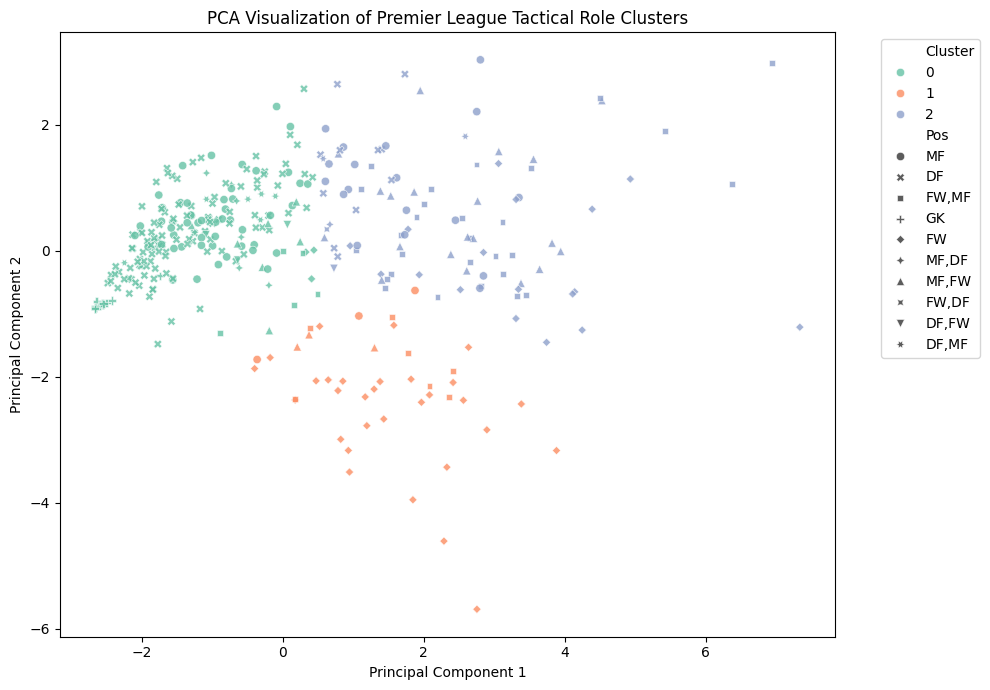

In [11]:
# Step 7: Visualize clusters using PCA

from sklearn.decomposition import PCA
import seaborn as sns

# Reduce the scaled features to 2 principal components
pca = PCA(n_components=2)
pca_components = pca.fit_transform(X_scaled)

# Add PCA components to the players dataframe
players["PC1"] = pca_components[:, 0]
players["PC2"] = pca_components[:, 1]

# Check how much variation the two components explain
explained_variance = pca.explained_variance_ratio_

print("Explained variance by PC1 and PC2:")
print(explained_variance)
print("Total explained variance:", explained_variance.sum().round(3))

# Plot the clusters
plt.figure(figsize=(10, 7))
sns.scatterplot(
    data=players,
    x="PC1",
    y="PC2",
    hue="Cluster",
    style="Pos",
    palette="Set2",
    alpha=0.8
)

plt.title("PCA Visualization of Premier League Tactical Role Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()


## Step 8: Review Example Players

Example players help connect the numerical clusters back to real football roles. This step lists high-minute players from each cluster so the results can be interpreted using recognizable player profiles.


In [12]:
# Step 8: Show example players from each cluster

# Display top example players from each cluster based on minutes played
for cluster in sorted(players["Cluster"].unique()):
    print(f"\nCluster {cluster} example players:")
    
    display(
        players[players["Cluster"] == cluster]
        .sort_values("Min", ascending=False)
        [[
            "Player", "Squad", "Pos", "Min",
            "Gls_per90", "Ast_per90", "npxG_per90", "xAG_per90",
            "PrgC_per90", "PrgP_per90", "PrgR_per90"
        ]]
        .head(10)
    )



Cluster 0 example players:


,Player,Squad,Pos,Min,Gls_per90,Ast_per90,npxG_per90,xAG_per90,PrgC_per90,PrgP_per90,PrgR_per90
303,Bernd Leno,Fulham,GK,3420,0.00,0.03,0.00,0.00,0.000000,0.000000,0.000000
464,Matz Sels,Nott'ham Forest,GK,3420,0.00,0.00,0.00,0.01,0.026316,0.052632,0.000000
234,Dean Henderson,Crystal Palace,GK,3420,0.00,0.00,0.00,0.00,0.000000,0.000000,0.000000
429,David Raya,Arsenal,GK,3420,0.00,0.00,0.00,0.00,0.000000,0.368421,0.000000
417,Jordan Pickford,Everton,GK,3420,0.00,0.03,0.00,0.01,0.000000,0.000000,0.000000
105,Nathan Collins,Brentford,DF,3420,0.05,0.08,0.07,0.05,0.842105,3.342105,0.473684
79,Moisés Caicedo,Chelsea,"MF,DF",3351,0.03,0.05,0.02,0.08,1.155914,5.779570,0.994624
284,Max Kilman,West Ham,DF,3348,0.00,0.03,0.04,0.03,0.833333,3.037634,0.161290
281,Milos Kerkez,Bournemouth,DF,3336,0.05,0.13,0.01,0.10,2.857143,4.285714,5.309973
530,Virgil van Dijk,Liverpool,DF,3330,0.08,0.03,0.06,0.02,0.594595,5.351351,0.162162



Cluster 1 example players:


,Player,Squad,Pos,Min,Gls_per90,Ast_per90,npxG_per90,xAG_per90,PrgC_per90,PrgP_per90,PrgR_per90
563,Chris Wood,Nott'ham Forest,FW,2959,0.61,0.09,0.34,0.08,0.425532,1.276596,2.857143
562,Yoane Wissa,Brentford,FW,2919,0.59,0.12,0.57,0.08,1.851852,2.067901,4.753086
531,Jamie Vardy,Leicester City,FW,2823,0.29,0.13,0.31,0.10,0.923567,0.700637,3.821656
252,Alexander Isak,Newcastle Utd,FW,2756,0.75,0.20,0.56,0.14,2.712418,2.875817,7.091503
224,Erling Haaland,Manchester City,FW,2736,0.72,0.10,0.62,0.10,0.789474,0.657895,4.078947
336,Jean-Philippe Mateta,Crystal Palace,FW,2648,0.48,0.07,0.41,0.11,1.530612,1.768707,4.149660
547,Ollie Watkins,Aston Villa,FW,2598,0.55,0.28,0.48,0.12,1.903114,1.072664,5.709343
127,Liam Delap,Ipswich Town,FW,2593,0.42,0.07,0.27,0.07,2.118056,1.041667,3.819444
494,Jørgen Strand Larsen,Wolves,FW,2587,0.49,0.14,0.36,0.10,0.592334,1.010453,3.902439
484,Tomáš Souček,West Ham,MF,2567,0.32,0.04,0.24,0.04,0.315789,2.596491,2.385965



Cluster 2 example players:


,Player,Squad,Pos,Min,Gls_per90,Ast_per90,npxG_per90,xAG_per90,PrgC_per90,PrgP_per90,PrgR_per90
340,Bryan Mbeumo,Brentford,FW,3414,0.53,0.18,0.20,0.22,3.430079,3.720317,9.261214
449,Mohamed Salah,Liverpool,FW,3371,0.77,0.48,0.49,0.38,4.133333,3.840000,13.013333
219,Bruno Guimarães,Newcastle Utd,MF,3271,0.14,0.17,0.12,0.17,1.763085,7.465565,2.644628
370,Daniel Muñoz,Crystal Palace,DF,3228,0.11,0.14,0.14,0.15,1.727019,2.701950,5.738162
466,Antoine Semenyo,Bournemouth,FW,3203,0.31,0.14,0.28,0.16,3.932584,3.061798,7.921348
407,Cole Palmer,Chelsea,"MF,FW",3191,0.42,0.23,0.38,0.31,3.380282,6.028169,5.267606
439,Antonee Robinson,Fulham,DF,3167,0.00,0.28,0.02,0.12,3.352273,3.721591,7.784091
444,Morgan Rogers,Aston Villa,"FW,MF",3114,0.23,0.29,0.19,0.23,3.294798,3.554913,5.433526
8,Rayan Aït-Nouri,Wolves,DF,3109,0.12,0.20,0.08,0.16,2.579710,3.130435,5.101449
509,Youri Tielemans,Aston Villa,MF,3026,0.09,0.21,0.07,0.21,1.160714,6.994048,1.428571


## Step 9: Add Tactical Role Names

After reviewing the cluster summaries and example players, the clusters are assigned descriptive tactical role names. These labels make the results easier to communicate in the final report.


In [13]:
# Step 9: Add descriptive tactical role names

cluster_names = {
    0: "Defensive / Low-Attacking Involvement",
    1: "Goal-Scoring Forwards",
    2: "Creative / Progressive Hybrid Attackers"
}

players["Tactical_Role"] = players["Cluster"].map(cluster_names)

# Preview the cluster labels
players[[
    "Player", "Squad", "Pos", "Cluster", "Tactical_Role",
    "Gls_per90", "Ast_per90", "npxG_per90", "xAG_per90",
    "PrgC_per90", "PrgP_per90", "PrgR_per90"
]].head(15)


,Player,Squad,Pos,Cluster,Tactical_Role,Gls_per90,Ast_per90,npxG_per90,xAG_per90,PrgC_per90,PrgP_per90,PrgR_per90
2,Tyler Adams,Bournemouth,MF,0,Defensive / Low-Attacking Involvement,0.00,0.14,0.07,0.05,0.642202,3.486239,0.458716
3,Tosin Adarabioyo,Chelsea,DF,0,Defensive / Low-Attacking Involvement,0.06,0.06,0.06,0.01,0.318471,2.675159,0.063694
4,Simon Adingra,Brighton,"FW,MF",2,Creative / Progressive Hybrid Attackers,0.16,0.16,0.20,0.20,4.098361,1.475410,11.147541
5,Emmanuel Agbadou,Wolves,DF,0,Defensive / Low-Attacking Involvement,0.06,0.00,0.05,0.02,0.382166,1.974522,0.127389
7,Ola Aina,Nott'ham Forest,DF,0,Defensive / Low-Attacking Involvement,0.06,0.03,0.02,0.04,2.012012,3.213213,2.012012
8,Rayan Aït-Nouri,Wolves,DF,2,Creative / Progressive Hybrid Attackers,0.12,0.20,0.08,0.16,2.579710,3.130435,5.101449
9,Kristoffer Ajer,Brentford,DF,0,Defensive / Low-Attacking Involvement,0.00,0.00,0.06,0.08,1.687500,3.500000,2.750000
10,Manuel Akanji,Manchester City,DF,0,Defensive / Low-Attacking Involvement,0.00,0.00,0.07,0.02,2.053571,7.053571,0.312500
11,Nathan Aké,Manchester City,DF,0,Defensive / Low-Attacking Involvement,0.00,0.00,0.03,0.00,1.600000,6.666667,0.266667
13,Carlos Alcaraz,Everton,"FW,MF",2,Creative / Progressive Hybrid Attackers,0.24,0.35,0.20,0.19,2.235294,4.941176,2.470588


## Step 10: Final PCA Visualization

This final PCA scatterplot uses the descriptive tactical role names rather than numeric cluster labels. It provides a cleaner visualization for presenting the main clustering result.


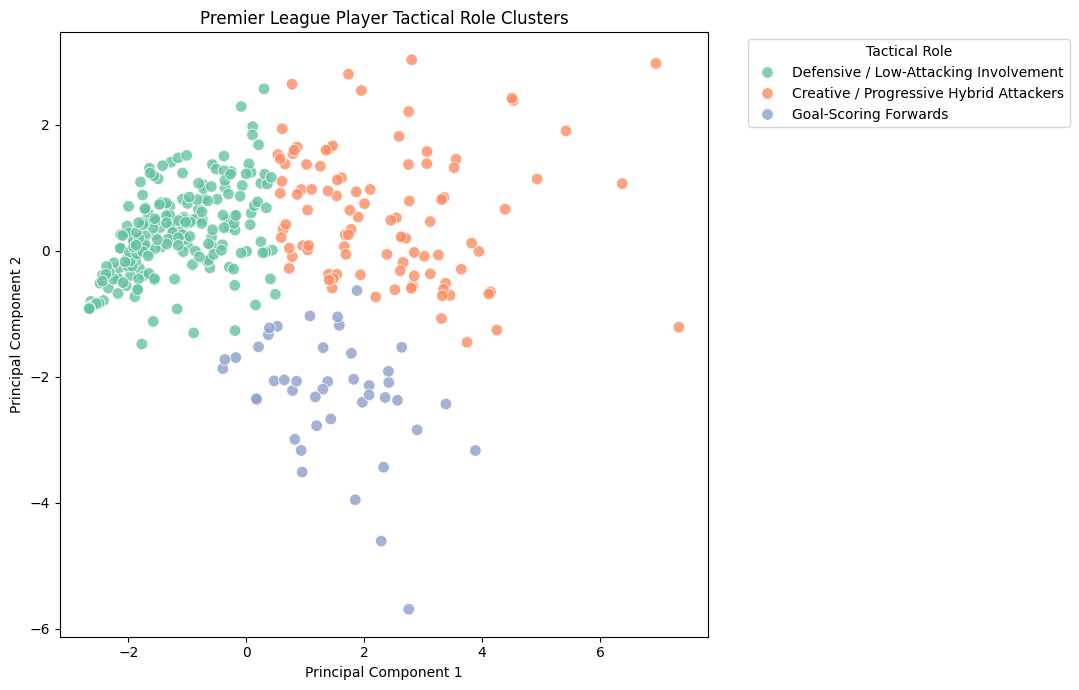

In [14]:
# Step 10: Final PCA visualization with tactical role names

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=players,
    x="PC1",
    y="PC2",
    hue="Tactical_Role",
    palette="Set2",
    alpha=0.8,
    s=70
)

plt.title("Premier League Player Tactical Role Clusters")
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.legend(title="Tactical Role", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.savefig("figures/final_pca_roles.png", dpi=300, bbox_inches="tight")
plt.show()


## Step 11: Compare Tactical Role Profiles

The heatmap compares average per-90 statistics across the three tactical roles. This makes the differences between the clusters easier to see, especially the contrast between goal-scoring forwards and creative/progressive hybrid attackers.


Average per-90 stats by tactical role:
                                         Gls_per90  Ast_per90  npxG_per90  \
Tactical_Role                                                               
Creative / Progressive Hybrid Attackers      0.211      0.213       0.186   
Defensive / Low-Attacking Involvement        0.041      0.042       0.049   
Goal-Scoring Forwards                        0.413      0.094       0.390   

                                         xAG_per90  PrgC_per90  PrgP_per90  \
Tactical_Role                                                                
Creative / Progressive Hybrid Attackers      0.204       3.388       4.191   
Defensive / Low-Attacking Involvement        0.051       1.028       3.243   
Goal-Scoring Forwards                        0.102       1.564       2.037   

                                         PrgR_per90  
Tactical_Role                                        
Creative / Progressive Hybrid Attackers       6.996  
Defensive / Low-Attack

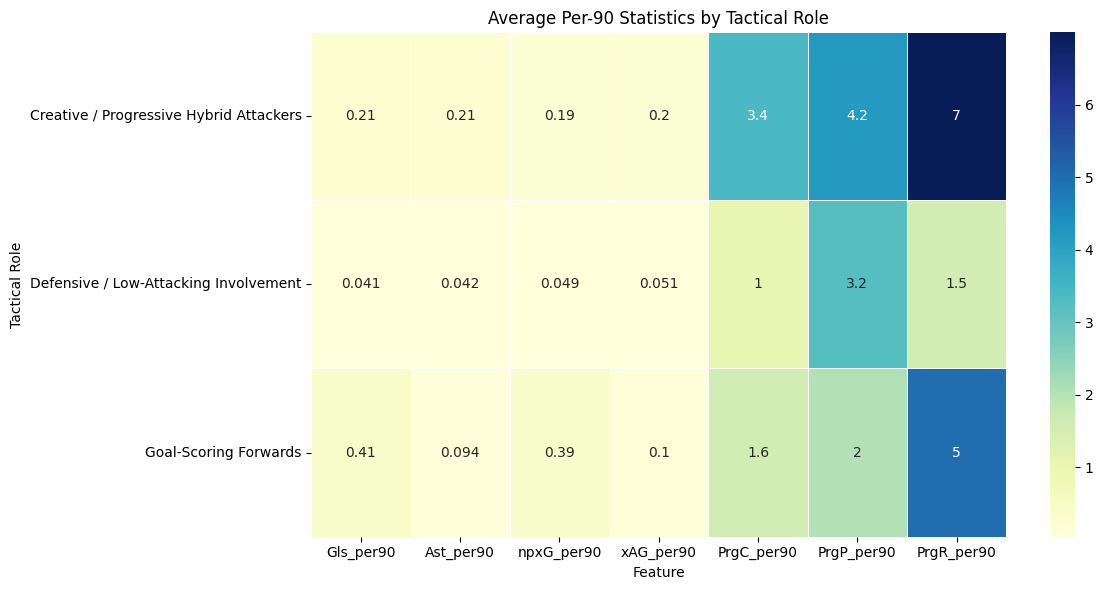

In [15]:
# Step 11: Compare average stats by tactical role

role_summary = players.groupby("Tactical_Role")[features].mean().round(3)

print("Average per-90 stats by tactical role:")
print(role_summary)

plt.figure(figsize=(12, 6))

sns.heatmap(
    role_summary,
    annot=True,
    cmap="YlGnBu",
    linewidths=0.5
)

plt.title("Average Per-90 Statistics by Tactical Role")
plt.xlabel("Feature")
plt.ylabel("Tactical Role")
plt.tight_layout()
plt.savefig("figures/tactical_role_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


## Conclusion

For this project, I used unsupervised machine learning to group Premier League players from the 2024/25 season into tactical roles based on per-90 attacking and progression statistics. After filtering out players with fewer than 600 minutes, I kept **369 players** from the original **574-player** dataset and used seven features: goals, assists, non-penalty expected goals, expected assisted goals, progressive carries, progressive passes, and progressive receptions.

Using K-Means clustering, the players were grouped into three tactical roles: **Defensive / Low-Attacking Involvement**, **Goal-Scoring Forwards**, and **Creative / Progressive Hybrid Attackers**. The clusters did not simply match traditional position labels. For example, the Creative / Progressive Hybrid Attackers cluster included forwards, attacking midfielders, central midfielders, and attack-minded defenders such as Trent Alexander-Arnold, Antonee Robinson, and Rayan Ait-Nouri.

The main finding is that unsupervised learning can reveal useful attacking and progression-based player profiles that do not always match traditional position labels. The Goal-Scoring Forwards cluster was defined mainly by high goals and non-penalty expected goals, while the Creative / Progressive Hybrid Attackers cluster stood out through assists, expected assisted goals, progressive carries, progressive passes, and progressive receptions.

I also compared K-Means with Agglomerative Clustering to make the analysis more rigorous. K-Means remained the main model because it produced a higher silhouette score than Agglomerative Clustering for the three-cluster setup and gave more interpretable tactical groupings.

One limitation is that the feature set is intentionally focused on attacking and progression metrics, so defensive actions, pressing, passing distance, goalkeeper-specific performance, and possession context are not fully represented. Goalkeepers are included in the dataset, but because the selected features are not goalkeeper-specific, their placement in the low-attacking cluster should be interpreted only within the scope of this model. Also, K-Means clustering requires choosing the number of clusters manually, so different feature choices or a different value of `k` could produce slightly different tactical groupings. The comparison with Agglomerative Clustering also showed that some assignments are sensitive to the algorithm used.

Overall, the analysis suggests that player roles in modern football are more complex than simple labels such as defender, midfielder, and forward. Statistical clustering can be a useful exploratory tool for finding broad attacking and progression-based tactical patterns.
